In [6]:
import pandas as pd
import numpy as np
import os
from google.colab import drive

drive.mount('/content/drive')

df_original = pd.read_csv('/content/drive/MyDrive/RESIDÊNCIA /Imersão /empregabilidade-ti-2019a2024.csv')

df = df_original.copy()

print("DataFrame carregado")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
DataFrame carregado


In [7]:
display(df.head(10))

,ano,sigla_uf,id_municipio,cbo_2002,cnae_2,sexo,idade,raca_cor,grau_instrucao_apos_2005,tipo_vinculo,tempo_emprego,mes_admissao,mes_desligamento,vinculo_ativo_3112,valor_remuneracao_media,valor_salario_contratual,subsetor_ibge,tamanho_estabelecimento,natureza_juridica
0,2019,CE,2304350.0,212420,46397,1,27,8,8,10,9.9,NaN,7.0,0,1272.33,NaN,17,7,2062.0
1,2019,RS,4314803.0,317210,47539,1,19,2,6,10,7.9,5.0,NaN,1,1344.47,NaN,16,6,2062.0
2,2019,RS,4314803.0,212420,15106,1,29,2,8,10,7.8,5.0,NaN,1,2624.93,NaN,9,6,2062.0
3,2019,RS,4314803.0,317210,61108,2,20,9,8,10,37.3,NaN,NaN,1,2166.17,NaN,20,4,2305.0
4,2019,AC,1200138.0,212420,82113,1,28,9,9,10,15.0,NaN,2.0,0,3500.00,NaN,19,5,2135.0
5,2019,AC,1200138.0,212420,82113,1,29,9,7,10,15.0,NaN,2.0,0,3500.00,NaN,19,5,2135.0
6,2023,MS,5002605.0,317210,61108,1,33,8,7,10,7.7,NaN,6.0,0,1385.96,NaN,20,4,2062.0
7,2023,PR,4106803.0,212410,61108,1,34,2,8,10,114.0,NaN,NaN,1,2950.02,NaN,20,4,2062.0
8,2024,SP,3547700.0,212405,1415,1,47,2,9,10,59.1,NaN,NaN,1,18488.21,NaN,25,7,2062.0
9,2024,SP,3547700.0,212415,82997,1,30,2,7,10,103.8,NaN,10.0,0,2167.49,NaN,19,1,2062.0


In [8]:
# criando coluna com valor do vinculo_ativo_3112
df['vinculo_ativo_3112_valor'] = np.where(df['vinculo_ativo_3112'] == 1, "sim", "não")

In [9]:
#criando coluna valor com sexo e raça_cor
sexo_valor = {
    1: 'masculino',
    9: 'not found',
    2: 'feminino',
    -1: 'ignorado'
}

raca_cor_valor = {
    99: 'not found',
    -1: 'ignorado',
    2: 'branca',
    4: 'preta',
    1: 'indigena',
    8: 'parda',
    6: 'amarela',
    9: 'nao identificado'
}

df['sexo_valor'] = df['sexo'].map(sexo_valor)
df['raca_cor_valor'] = df['raca_cor'].map(raca_cor_valor)

display(df.head(10))

,ano,sigla_uf,id_municipio,cbo_2002,cnae_2,sexo,idade,raca_cor,grau_instrucao_apos_2005,tipo_vinculo,...,mes_desligamento,vinculo_ativo_3112,valor_remuneracao_media,valor_salario_contratual,subsetor_ibge,tamanho_estabelecimento,natureza_juridica,vinculo_ativo_3112_valor,sexo_valor,raca_cor_valor
0,2019,CE,2304350.0,212420,46397,1,27,8,8,10,...,7.0,0,1272.33,NaN,17,7,2062.0,não,masculino,parda
1,2019,RS,4314803.0,317210,47539,1,19,2,6,10,...,NaN,1,1344.47,NaN,16,6,2062.0,sim,masculino,branca
2,2019,RS,4314803.0,212420,15106,1,29,2,8,10,...,NaN,1,2624.93,NaN,9,6,2062.0,sim,masculino,branca
3,2019,RS,4314803.0,317210,61108,2,20,9,8,10,...,NaN,1,2166.17,NaN,20,4,2305.0,sim,feminino,nao identificado
4,2019,AC,1200138.0,212420,82113,1,28,9,9,10,...,2.0,0,3500.00,NaN,19,5,2135.0,não,masculino,nao identificado
5,2019,AC,1200138.0,212420,82113,1,29,9,7,10,...,2.0,0,3500.00,NaN,19,5,2135.0,não,masculino,nao identificado
6,2023,MS,5002605.0,317210,61108,1,33,8,7,10,...,6.0,0,1385.96,NaN,20,4,2062.0,não,masculino,parda
7,2023,PR,4106803.0,212410,61108,1,34,2,8,10,...,NaN,1,2950.02,NaN,20,4,2062.0,sim,masculino,branca
8,2024,SP,3547700.0,212405,1415,1,47,2,9,10,...,NaN,1,18488.21,NaN,25,7,2062.0,sim,masculino,branca
9,2024,SP,3547700.0,212415,82997,1,30,2,7,10,...,10.0,0,2167.49,NaN,19,1,2062.0,não,masculino,branca


In [10]:
# Criando coluna com valor do tamanho do estabelecimento e grau_instrucao_apos_2005

tamanho_estabelecimento_valor = {
    -1: 'Ignorado',
     0: 'ZERO',
     1: 'ZERO',
     2: 'Até 4',
     3: 'De 5 a 9',
     4: 'De 10 a 19',
     5: 'De 20 a 49',
     6: 'De 50 a 99',
     7: 'De 100 a 249',
     8: 'De 250 a 499',
     9: 'De 500 a 999',
    10: '1000 ou mais'
}

grau_instrucao_apos_2005_valor = {
    -1: 'IGNORADO',
     1: 'ANALFABETO',
     2: 'ATE 5.A INC',
     3: '5.A CO FUND',
     4: '6. A 9. FUND',
     5: 'FUND COMPL',
     6: 'MEDIO INCOMP',
     7: 'MEDIO COMPL',
     8: 'SUP. INCOMP',
     9: 'SUP. COMP',
    10: 'MESTRADO',
    11: 'DOUTORADO',
    99: 'Código não encontrado nos dicionários oficiais.'
}

df['tamanho_estabelecimento_valor'] = df['tamanho_estabelecimento'].map(tamanho_estabelecimento_valor)
df['grau_instrucao_apos_2005_valor'] = df['grau_instrucao_apos_2005'].map(grau_instrucao_apos_2005_valor)

display(df.head(5))

,ano,sigla_uf,id_municipio,cbo_2002,cnae_2,sexo,idade,raca_cor,grau_instrucao_apos_2005,tipo_vinculo,...,valor_remuneracao_media,valor_salario_contratual,subsetor_ibge,tamanho_estabelecimento,natureza_juridica,vinculo_ativo_3112_valor,sexo_valor,raca_cor_valor,tamanho_estabelecimento_valor,grau_instrucao_apos_2005_valor
0,2019,CE,2304350.0,212420,46397,1,27,8,8,10,...,1272.33,NaN,17,7,2062.0,não,masculino,parda,De 100 a 249,SUP. INCOMP
1,2019,RS,4314803.0,317210,47539,1,19,2,6,10,...,1344.47,NaN,16,6,2062.0,sim,masculino,branca,De 50 a 99,MEDIO INCOMP
2,2019,RS,4314803.0,212420,15106,1,29,2,8,10,...,2624.93,NaN,9,6,2062.0,sim,masculino,branca,De 50 a 99,SUP. INCOMP
3,2019,RS,4314803.0,317210,61108,2,20,9,8,10,...,2166.17,NaN,20,4,2305.0,sim,feminino,nao identificado,De 10 a 19,SUP. INCOMP
4,2019,AC,1200138.0,212420,82113,1,28,9,9,10,...,3500.00,NaN,19,5,2135.0,não,masculino,nao identificado,De 20 a 49,SUP. COMP


In [19]:
# Carregando dataset com valor natureza juridica
#path_natureza_juridica = '/content/drive/MyDrive/RESIDÊNCIA /Imersão /Dicionário/id-natureza-juridica.gsheet'


df_natureza_juridica = pd.read_csv('/content/drive/MyDrive/RESIDÊNCIA /Imersão /Dicionário/br_bd_diretorios_brasil_natureza_juridica.csv')

print("--- Natureza Jurídica carregada: ---")
print(df_natureza_juridica.head())
print("\n")

--- Natureza Jurídica carregada: ---
   id_natureza_juridica      descricao  \
0                  1341          União   
1                  4111      Leiloeiro   
2                  1244      Município   
3                  2143    Cooperativa   
4                  3247  Fundo Privado   

                                              escopo  
0  a União, ente federativo com personalidade jur...  
1  o leiloeiro oficial (Decreto Federal n. º 21.9...  
2  os Municípios, pessoas jurídicas de direito pú...  
3  as sociedades de pessoas que se obrigam, atrav...  
4  os fundos garantidores de parcerias público-pr...  




In [20]:

# fazendo left join com o valor natureza juridica
columns_df_natureza_juridica = df_natureza_juridica[['id_natureza_juridica', 'descricao']]

df = pd.merge(
        df,
        columns_df_natureza_juridica,
        left_on= 'natureza_juridica',
        right_on= 'id_natureza_juridica',
        how='left'
    )


print("join realizado com sucesso")

# padronizar o nome das colunas com valor
df = df.rename(columns={
    'descricao': 'natureza_juridica_valor'
})

display(df.head(5))

join realizado com sucesso


,ano,sigla_uf,id_municipio,cbo_2002,cnae_2,sexo,idade,raca_cor,grau_instrucao_apos_2005,tipo_vinculo,...,subsetor_ibge,tamanho_estabelecimento,natureza_juridica,vinculo_ativo_3112_valor,sexo_valor,raca_cor_valor,tamanho_estabelecimento_valor,grau_instrucao_apos_2005_valor,id_natureza_juridica,natureza_juridica_valor
0,2019,CE,2304350.0,212420,46397,1,27,8,8,10,...,17,7,2062.0,não,masculino,parda,De 100 a 249,SUP. INCOMP,2062.0,Sociedade Empresária Limitada
1,2019,RS,4314803.0,317210,47539,1,19,2,6,10,...,16,6,2062.0,sim,masculino,branca,De 50 a 99,MEDIO INCOMP,2062.0,Sociedade Empresária Limitada
2,2019,RS,4314803.0,212420,15106,1,29,2,8,10,...,9,6,2062.0,sim,masculino,branca,De 50 a 99,SUP. INCOMP,2062.0,Sociedade Empresária Limitada
3,2019,RS,4314803.0,317210,61108,2,20,9,8,10,...,20,4,2305.0,sim,feminino,nao identificado,De 10 a 19,SUP. INCOMP,2305.0,Empresa Individual de Responsabilidade Limitad...
4,2019,AC,1200138.0,212420,82113,1,28,9,9,10,...,19,5,2135.0,não,masculino,nao identificado,De 20 a 49,SUP. COMP,2135.0,Empresário (Individual)


In [21]:
df = df.drop(columns=['id_natureza_juridica'])

In [24]:
# Carregando dataset com valor do municipio
#path_municipio = '/content/drive/MyDrive/RESIDÊNCIA /Imersão /Dicionário/br_bd_diretorios_brasil_municipio.csv'

df_municipio = pd.read_csv('/content/drive/MyDrive/RESIDÊNCIA /Imersão /Dicionário/br_bd_diretorios_brasil_municipio.csv')

print("--- municipio carregado: ---")
print(df_municipio.head())
print("\n")


--- municipio carregado: ---
   id_municipio  id_municipio_6  id_municipio_tse  id_municipio_rf  \
0       5101837          510183               NaN              NaN   
1       1100809          110080             477.0            681.0   
2       1100338          110033             434.0             47.0   
3       1100205          110020              35.0              3.0   
4       1101104          110110             493.0            683.0   

   id_municipio_bcb                    nome  capital_uf  id_comarca  \
0               NaN  Boa Esperança do Norte         NaN         NaN   
1           46961.0      Candeias do Jamari         0.0   1100205.0   
2           44516.0             Nova Mamoré         0.0   1100106.0   
3           30719.0             Porto Velho         1.0   1100205.0   
4           46851.0         Itapuã do Oeste         0.0   1100205.0   

   id_regiao_saude nome_regiao_saude  ...  nome_mesorregiao  \
0              NaN               NaN  ...               NaN 

In [25]:
# fazendo left join com o valor municipio
columns_df_municipio = df_municipio[['id_municipio', 'nome']]

df = pd.merge(
        df,
        columns_df_municipio,
        left_on= 'id_municipio',
        right_on= 'id_municipio',
        how='left'
    )


print("join realizado com sucesso")

# apagando foreign key
df = df.drop(columns=['id_municipio'])

print("foreign key apagada")

display(df.head(5))

join realizado com sucesso
foreign key apagada


,ano,sigla_uf,cbo_2002,cnae_2,sexo,idade,raca_cor,grau_instrucao_apos_2005,tipo_vinculo,tempo_emprego,...,subsetor_ibge,tamanho_estabelecimento,natureza_juridica,vinculo_ativo_3112_valor,sexo_valor,raca_cor_valor,tamanho_estabelecimento_valor,grau_instrucao_apos_2005_valor,natureza_juridica_valor,nome
0,2019,CE,212420,46397,1,27,8,8,10,9.9,...,17,7,2062.0,não,masculino,parda,De 100 a 249,SUP. INCOMP,Sociedade Empresária Limitada,Forquilha
1,2019,RS,317210,47539,1,19,2,6,10,7.9,...,16,6,2062.0,sim,masculino,branca,De 50 a 99,MEDIO INCOMP,Sociedade Empresária Limitada,Portão
2,2019,RS,212420,15106,1,29,2,8,10,7.8,...,9,6,2062.0,sim,masculino,branca,De 50 a 99,SUP. INCOMP,Sociedade Empresária Limitada,Portão
3,2019,RS,317210,61108,2,20,9,8,10,37.3,...,20,4,2305.0,sim,feminino,nao identificado,De 10 a 19,SUP. INCOMP,Empresa Individual de Responsabilidade Limitad...,Portão
4,2019,AC,212420,82113,1,28,9,9,10,15.0,...,19,5,2135.0,não,masculino,nao identificado,De 20 a 49,SUP. COMP,Empresário (Individual),Bujari


In [26]:
# Carregando dataset com valor do mprofissoes
#path_profissoes_ti = '/content/profissoes-ti-valor.xlsx'

df_profissoes_ti = pd.read_csv('/content/drive/MyDrive/RESIDÊNCIA /Imersão /Dicionário/profissoes-ti.csv')

print("--- profissoes ti carregado: ---")
print(df_profissoes_ti.head())
print("\n")

--- profissoes ti carregado: ---
   cbo_2002                                       descricao  familia  \
0    123605             Diretor De Tecnologia Da Informação     1236   
1    131215                  Tecnólogo Em Gestão Hospitalar     1312   
2    142120  Tecnólogo Em Gestão Administrativo- Financeira     1421   
3    142130                              Analista De Riscos     1421   
4    142135     Oficial De Proteção De Dados Pessoais (Dpo)     1421   

                                   descricao_familia  subgrupo  \
0              Diretores de tecnologia da informação       123   
1  Gestores e especialistas de operações em empre...       131   
2  Gerentes administrativos, financeiros, de risc...       142   
3  Gerentes administrativos, financeiros, de risc...       142   
4  Gerentes administrativos, financeiros, de risc...       142   

                                  descricao_subgrupo  subgrupo_principal  \
0                        Diretores De Áreas De Apoio         

In [27]:
# fazendo left join com o valor profissoes ti
columns_profissoes_ti = df_profissoes_ti[['cbo_2002', 'descricao', 'familia', 'descricao_familia', 'subgrupo', 'descricao_subgrupo']]

df = pd.merge(
        df,
        columns_profissoes_ti,
        left_on= 'cbo_2002',
        right_on= 'cbo_2002',
        how='left'
    )


print("join realizado com sucesso")

# apagando foreign key
df = df.drop(columns=['cbo_2002'])

print("foreign key apagada")

display(df.head(5))

join realizado com sucesso
foreign key apagada


,ano,sigla_uf,cnae_2,sexo,idade,raca_cor,grau_instrucao_apos_2005,tipo_vinculo,tempo_emprego,mes_admissao,...,raca_cor_valor,tamanho_estabelecimento_valor,grau_instrucao_apos_2005_valor,natureza_juridica_valor,nome,descricao,familia,descricao_familia,subgrupo,descricao_subgrupo
0,2019,CE,46397,1,27,8,8,10,9.9,NaN,...,parda,De 100 a 249,SUP. INCOMP,Sociedade Empresária Limitada,Forquilha,Analista De Suporte Computacional,2124,Analistas de tecnologia da informação,212,Profissionais Da Informática
1,2019,RS,47539,1,19,2,6,10,7.9,5.0,...,branca,De 50 a 99,MEDIO INCOMP,Sociedade Empresária Limitada,Portão,Técnico De Suporte Ao Usuário De Tecnologia Da...,3172,Técnicos de suporte e monitoração ao usuário d...,317,Técnicos Em Informática
2,2019,RS,15106,1,29,2,8,10,7.8,5.0,...,branca,De 50 a 99,SUP. INCOMP,Sociedade Empresária Limitada,Portão,Analista De Suporte Computacional,2124,Analistas de tecnologia da informação,212,Profissionais Da Informática
3,2019,RS,61108,2,20,9,8,10,37.3,NaN,...,nao identificado,De 10 a 19,SUP. INCOMP,Empresa Individual de Responsabilidade Limitad...,Portão,Técnico De Suporte Ao Usuário De Tecnologia Da...,3172,Técnicos de suporte e monitoração ao usuário d...,317,Técnicos Em Informática
4,2019,AC,82113,1,28,9,9,10,15.0,NaN,...,nao identificado,De 20 a 49,SUP. COMP,Empresário (Individual),Bujari,Analista De Suporte Computacional,2124,Analistas de tecnologia da informação,212,Profissionais Da Informática


In [29]:
df.to_csv('df_processed.csv', index=False)
print("DataFrame saved to df_processed.csv")

DataFrame saved to df_processed.csv


In [31]:
from google.colab import files

files.download('/content/df_processed.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [33]:
display(df['descricao_familia'].value_counts())

,count
descricao_familia,
Analistas de tecnologia da informação,638263
Técnicos de desenvolvimento de sistemas e aplicações,181005
Técnicos de suporte e monitoração ao usuário de tecnologia da informação.,167831
Administradores de tecnologia da informação,54893
Engenheiros em computação,25026


/tmp/ipython-input-3057723341.py:14: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


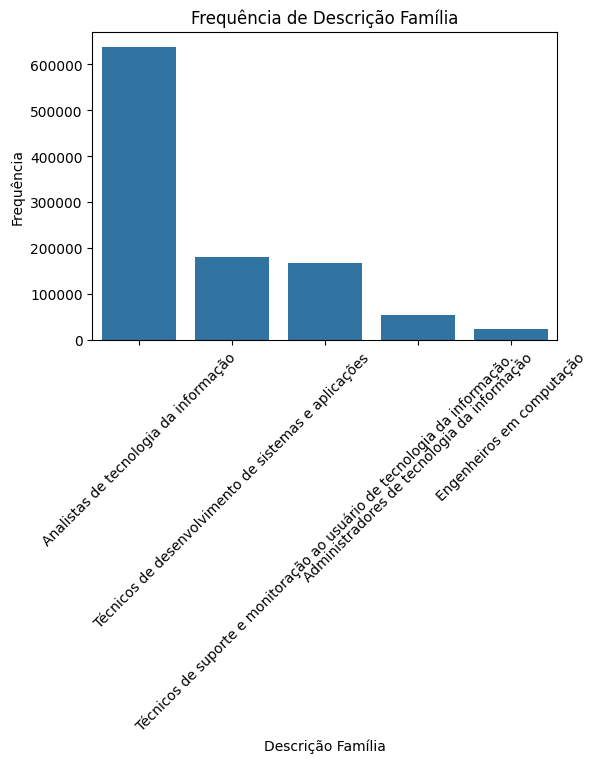

In [37]:
import matplotlib.pyplot as plt
import seaborn as sns

count_familia = df['descricao_familia'].value_counts()
count_natureza_juridica = df['natureza_juridica_valor'].value_counts()


plt.figure(figsize=(6, 4))
sns.barplot(x=count_familia.index, y=count_familia.values)
plt.xticks(rotation=45)
plt.ylabel('Frequência')
plt.title('Frequência de Descrição Família')
plt.tight_layout()
plt.show()